# California Housing Price Prediction with Extended Ensemble Models

This notebook implements a comprehensive machine learning pipeline that combines dimensionality reduction (PCA) with a diverse heterogeneous ensemble learning regression model (Voting Regressor) to predict house prices using the California Housing dataset.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Import a wide variety of regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor

from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

## 1. Load the Dataset

In [20]:
# Load the California Housing dataset
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = pd.Series(california.target, name='MedHouseVal')

print(f"Dataset shape: {X.shape}")
X.head()

Dataset shape: (20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## 2. Exploratory Data Analysis (EDA)
Before building the pipeline, let's visualize the raw data to understand relationships and distributions.

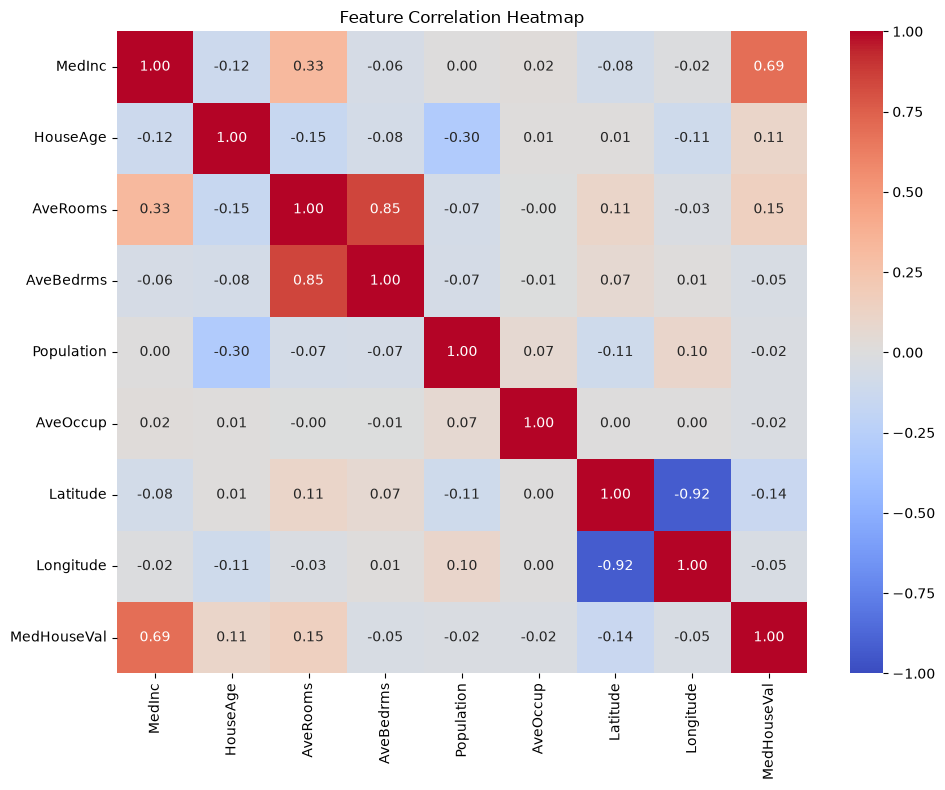

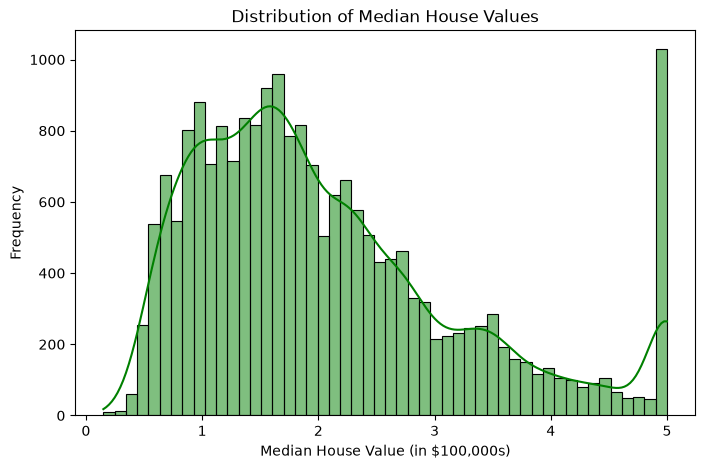

In [21]:
# Plot correlation heatmap
plt.figure(figsize=(10, 8))
data_for_corr = X.copy()
data_for_corr['MedHouseVal'] = y
sns.heatmap(data_for_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Plot distribution of the target variable
plt.figure(figsize=(8, 5))
sns.histplot(y, kde=True, bins=50, color='green')
plt.title('Distribution of Median House Values')
plt.xlabel('Median House Value (in $100,000s)')
plt.ylabel('Frequency')
plt.show()

### EDA Observations:
- **MedInc (Median Income)** has the strongest positive correlation (0.69) with the target variable `MedHouseVal`.
- The target variable distribution shows a long tail and a hard cap at 5.0 ($500,000), which is a quirk of this specific dataset.

## 3. Data Preprocessing & Cleaning
In a robust ML pipeline, we must check for missing values and ensure the data is ready for modeling. 
Note: Feature scaling (Standardization) is required for PCA and distance-based models (like KNN and SVR). Instead of doing it manually here, we will embed the `StandardScaler` directly into our Scikit-Learn `Pipeline` to prevent data leakage.

In [22]:
# Check for missing values
missing_values = X.isnull().sum()
print("Missing values in each feature:")
print(missing_values)

if missing_values.sum() == 0:
    print("\nObservation: The dataset has no missing values. We can proceed without imputation.")
else:
    print("\nObservation: Missing values detected. Imputation would be required.")

Missing values in each feature:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

Observation: The dataset has no missing values. We can proceed without imputation.


## 4. Train-Test Split
We split the data before applying transformations (like PCA) to ensure the test set remains completely unseen.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 16512
Testing set size: 4128


## 5. PCA Analysis
Let's see how much variance is explained by the Principal Components to justify our parameter choices.

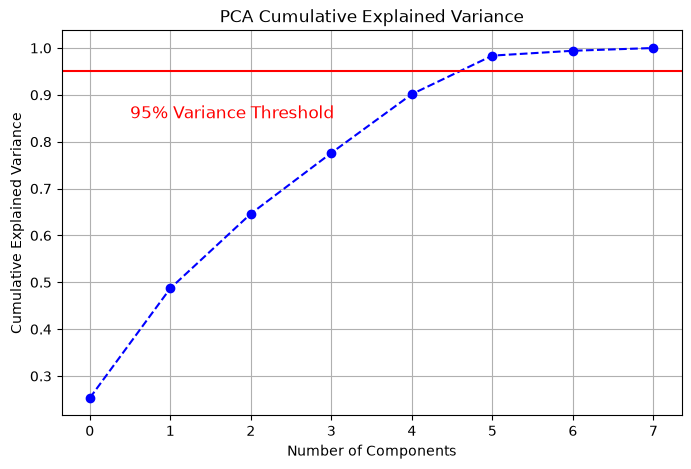

In [24]:
# We fit PCA only on the scaled training data for this visualization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
pca = PCA().fit(X_train_scaled)

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--', color='b')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(0.5, 0.85, '95% Variance Threshold', color='red', fontsize=12)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.grid(True)
plt.show()

## 6. Build the Machine Learning Pipeline

We create a comprehensive pipeline consisting of:
1. **StandardScaler**: Standardizes features to have mean=0 and variance=1.
2. **PCA**: Dimensionality reduction retaining 95% of the variance.
3. **Ensemble Regressor**: A Voting Regressor that averages predictions across 9 diverse models.

In [25]:
# Define the base models for the ensemble
estimators = [
    ('lr', LinearRegression()),
    ('ridge', Ridge(alpha=1.0)),
    ('lasso', Lasso(alpha=0.1)),
    ('elasticnet', ElasticNet(alpha=0.1, l1_ratio=0.5)),
    ('knn', KNeighborsRegressor(n_neighbors=5)),
    ('svr', SVR(C=1.0, epsilon=0.2)),
    ('dt', DecisionTreeRegressor(max_depth=5, random_state=42)),
    ('rf', RandomForestRegressor(n_estimators=50, random_state=42)),
    ('gbr', GradientBoostingRegressor(n_estimators=50, random_state=42))
]

# Create an ensemble model (Voting Regressor)
ensemble_model = VotingRegressor(estimators=estimators)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('ensemble', ensemble_model)
])

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",0.95
,"random_state random_state: int, RandomState instance or None, default=NoneUsed when the 'arpack' or 'randomized' solvers are used. Pass an intfor reproducible results across multiple function calls.See :term:`Glossary <random_state>`... versionadded:: 0.18.0",42
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-

## 7. Train the Model

In [26]:
# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


## 8. Evaluate the Model

In [27]:
# Make predictions on the test set
y_pred = pipeline.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2 Score): {r2:.4f}")

Root Mean Squared Error (RMSE): 0.7390
R-squared (R2 Score): 0.5833


## 9. Model Visualizations

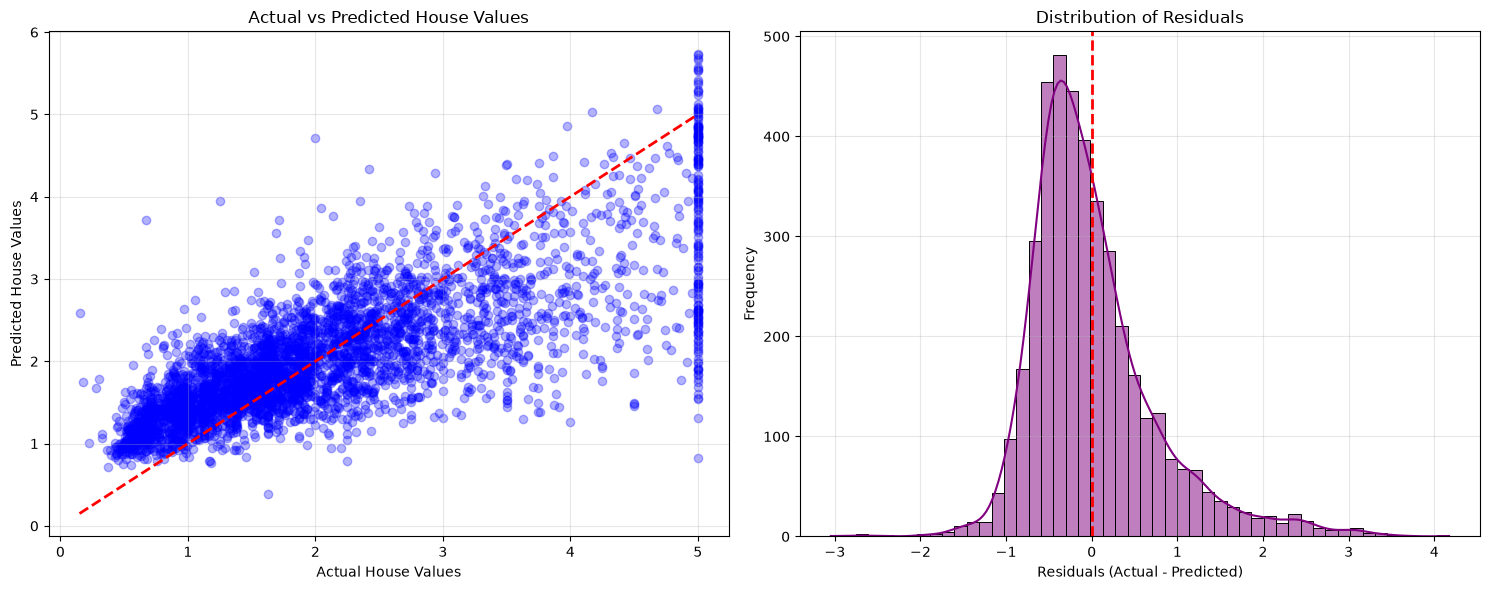

In [28]:
plt.figure(figsize=(15, 6))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual House Values')
plt.ylabel('Predicted House Values')
plt.title('Actual vs Predicted House Values')
plt.grid(True, alpha=0.3)

# Plot 2: Residual Distribution
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='purple', bins=50)
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Visualization Observations:
1. **Actual vs Predicted (Left)**: Most points are clustered closely around the red line (perfect prediction). The model handles general trends well, though it struggles slightly with the artificial price cap at $500,000 (visible as a vertical line of dots on the far right).
2. **Residual Distribution (Right)**: The errors are normally distributed and centered around zero, indicating that the ensemble model is unbiased.

## 10. Inference: Predicting on New Data

Let's simulate how the model would perform in a real-world scenario.

In [29]:
# Select a few samples for inference
sample_data = X_test.iloc[:5]
actual_values = y_test.iloc[:5]

# Perform inference (predicting)
predicted_values = pipeline.predict(sample_data)

print("--- INFERENCE RESULTS ---")
for i in range(len(sample_data)):
    print(f"\nSample {i+1}:")
    print(f"Predicted House Value: ${predicted_values[i] * 100000:,.2f}")
    print(f"Actual House Value:    ${actual_values.iloc[i] * 100000:,.2f}")
    
    difference = abs(predicted_values[i] - actual_values.iloc[i]) * 100000
    print(f"Difference:            ${difference:,.2f}")

--- INFERENCE RESULTS ---

Sample 1:
Predicted House Value: $100,919.62
Actual House Value:    $47,700.00
Difference:            $53,219.62

Sample 2:
Predicted House Value: $126,907.86
Actual House Value:    $45,800.00
Difference:            $81,107.86

Sample 3:
Predicted House Value: $276,903.41
Actual House Value:    $500,001.00
Difference:            $223,097.59

Sample 4:
Predicted House Value: $264,312.68
Actual House Value:    $218,600.00
Difference:            $45,712.68

Sample 5:
Predicted House Value: $212,376.70
Actual House Value:    $278,000.00
Difference:            $65,623.30
